In [6]:
#installing the libararies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import warnings
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.seasonal import seasonal_decompose


In [7]:
#load our dataset
df = pd.read_csv('../data/gas_price_2526.csv')

#display basic information
print(df.info())
#display the first 5 rows
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   date         500 non-null    object 
 1   daily price  500 non-null    float64
dtypes: float64(1), object(1)
memory usage: 7.9+ KB
None


,date,daily price
0,19/01/2025,39.85
1,20/01/2025,37.21
2,21/01/2025,37.33
3,22/01/2025,37.85
4,23/01/2025,35.70


In [8]:
# date is object(means string) convert into date and time object
df['date'] = pd.to_datetime(df['date'], format='%d/%m/%Y') #(dd/mm/yyyy)

#set date column as index(TS)
df.set_index('date', inplace=True)



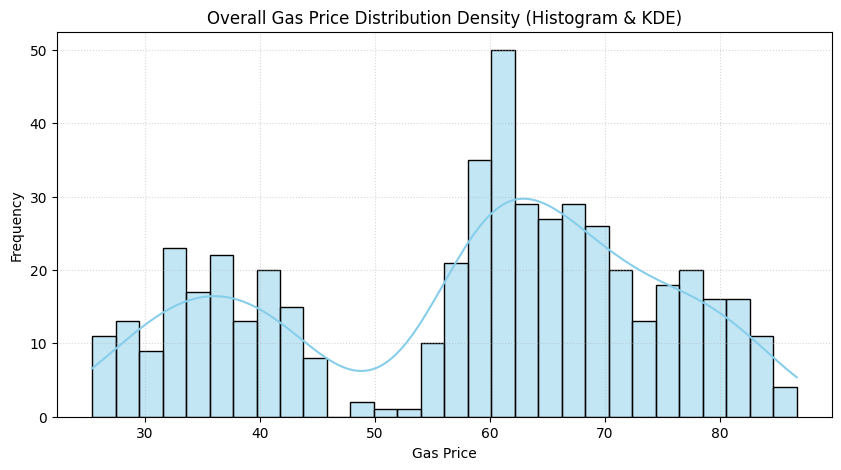

In [9]:
# Plotting overall density spread of the target asset
plt.figure(figsize=(10, 5))
sns.histplot(df['daily price'], kde=True, color='skyblue', bins=30)
plt.title('Overall Gas Price Distribution Density (Histogram & KDE)')
plt.xlabel('Gas Price')
plt.ylabel('Frequency')
plt.grid(True, linestyle=':', alpha=0.5)
plt.show()

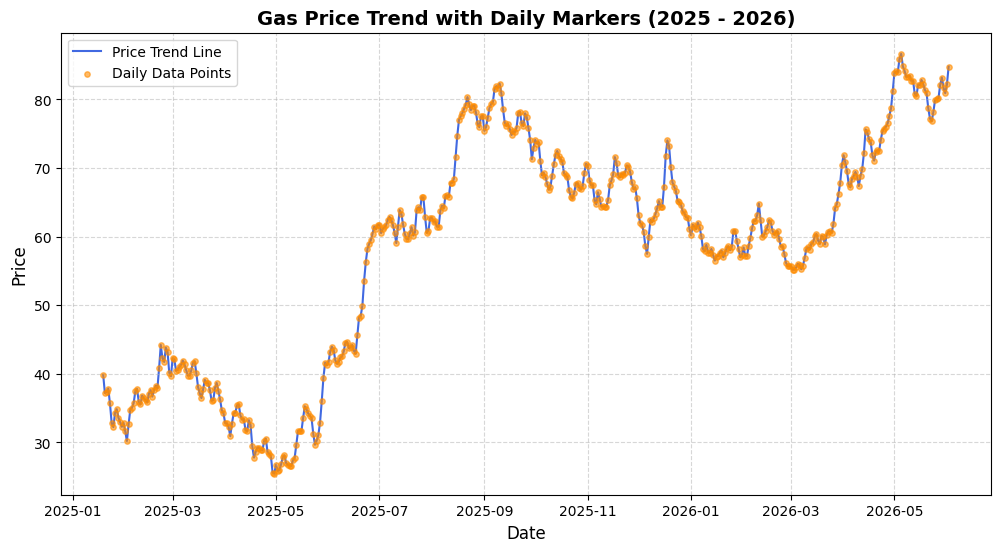

In [10]:
#line and scatter plot
plt.figure(figsize=(12, 6))

#continuous line
plt.plot(df.index, df['daily price'], color='royalblue', linewidth=1.5, label='Price Trend Line', zorder=1)
#s => size of dot, alpha=>transparency, =
plt.scatter(df.index, df['daily price'], color='darkorange', s=15, alpha=0.6, label='Daily Data Points', zorder=2)

plt.title('Gas Price Trend with Daily Markers (2025 - 2026)', fontsize=14, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.show()

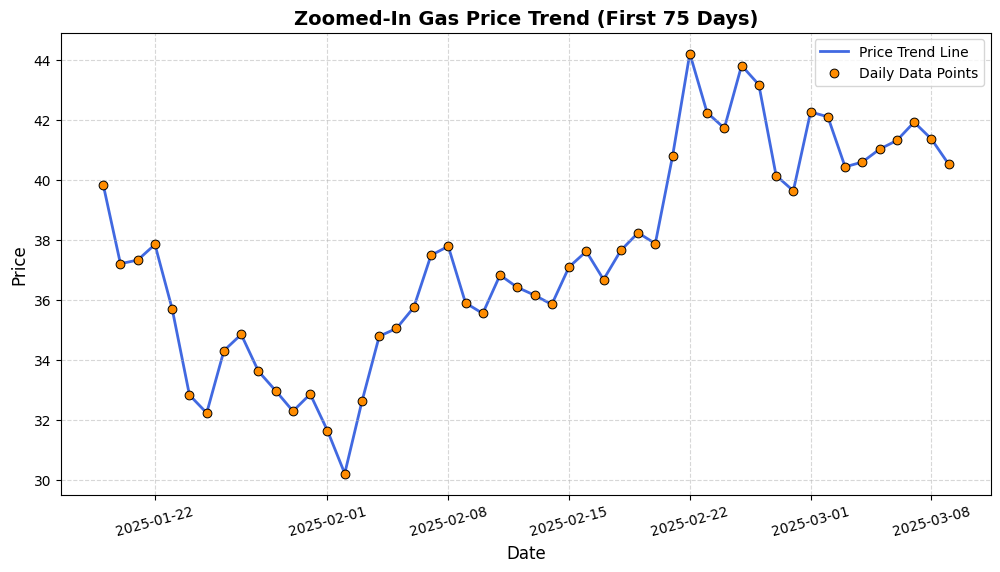

In [11]:
#too clumsy with all 500 pts, zoom for 10% 50 datapoints (first 50 data points)
df_zoom = df.iloc[0:50]

plt.figure(figsize=(12, 6))

#line for 50 pts
plt.plot(df_zoom.index, df_zoom['daily price'], color='royalblue', linewidth=2, label='Price Trend Line', zorder=1)

#add dots(scatter points/data points for the same timeframe)
plt.scatter(df_zoom.index, df_zoom['daily price'], color='darkorange', s=40, edgecolors='black', linewidth=0.7, label='Daily Data Points', zorder=2)

plt.title('Zoomed-In Gas Price Trend (First 75 Days)', fontsize=14, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.xticks(rotation=15)
plt.show()

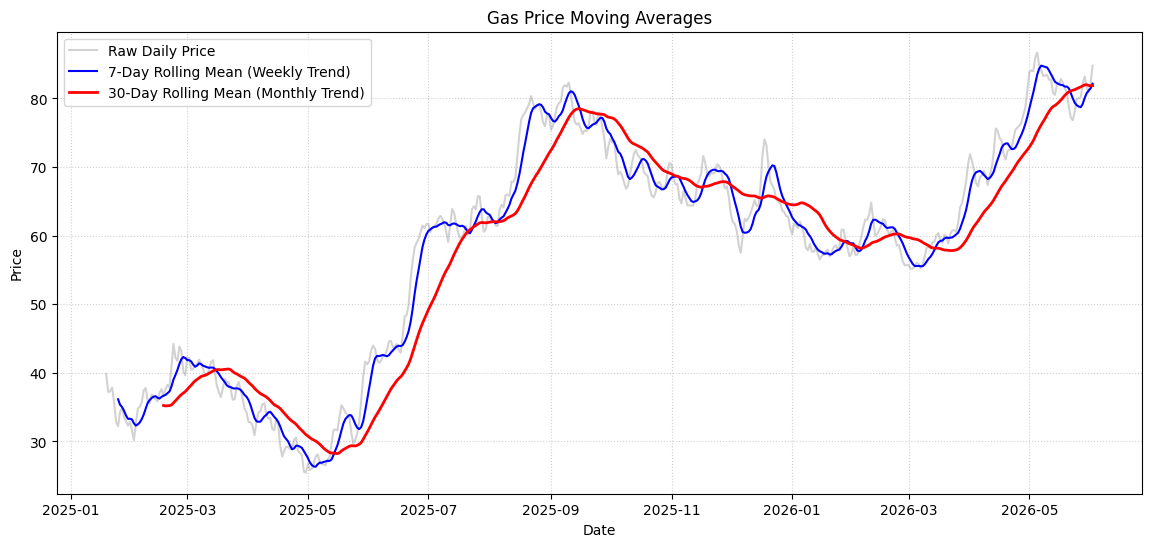

In [12]:
# Extracting short-term and medium-term rolling trends
plt.figure(figsize=(14, 6))
plt.plot(df.index, df['daily price'], label='Raw Daily Price', color='gray', alpha=0.35)
plt.plot(df.index, df['daily price'].rolling(window=7).mean(), label='7-Day Rolling Mean (Weekly Trend)', color='blue', lw=1.5)
plt.plot(df.index, df['daily price'].rolling(window=30).mean(), label='30-Day Rolling Mean (Monthly Trend)', color='red', lw=2)
plt.title('Gas Price Moving Averages')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend(loc='upper left')
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

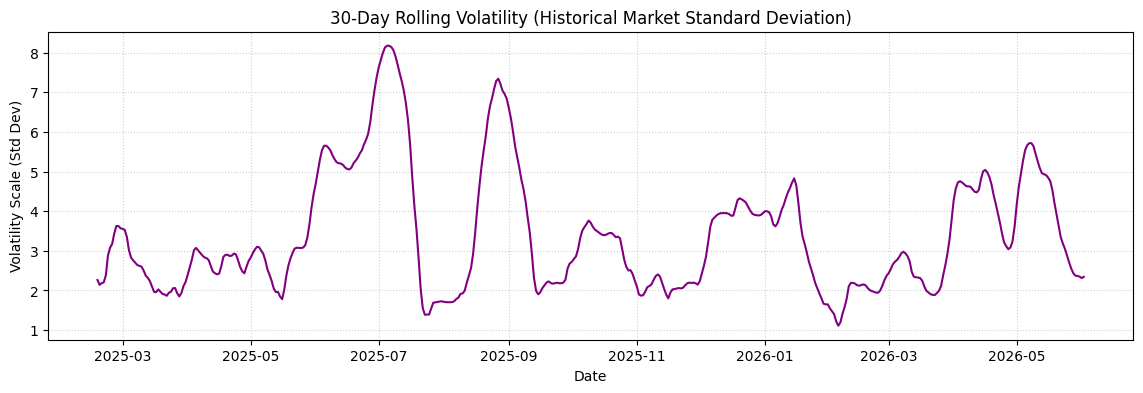

In [13]:
# Evaluating rolling volatility shifts across the dataset
plt.figure(figsize=(14, 4))
plt.plot(df.index, df['daily price'].rolling(window=30).std(), color='purple', lw=1.5)
plt.title('30-Day Rolling Volatility (Historical Market Standard Deviation)')
plt.xlabel('Date')
plt.ylabel('Volatility Scale (Std Dev)')
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

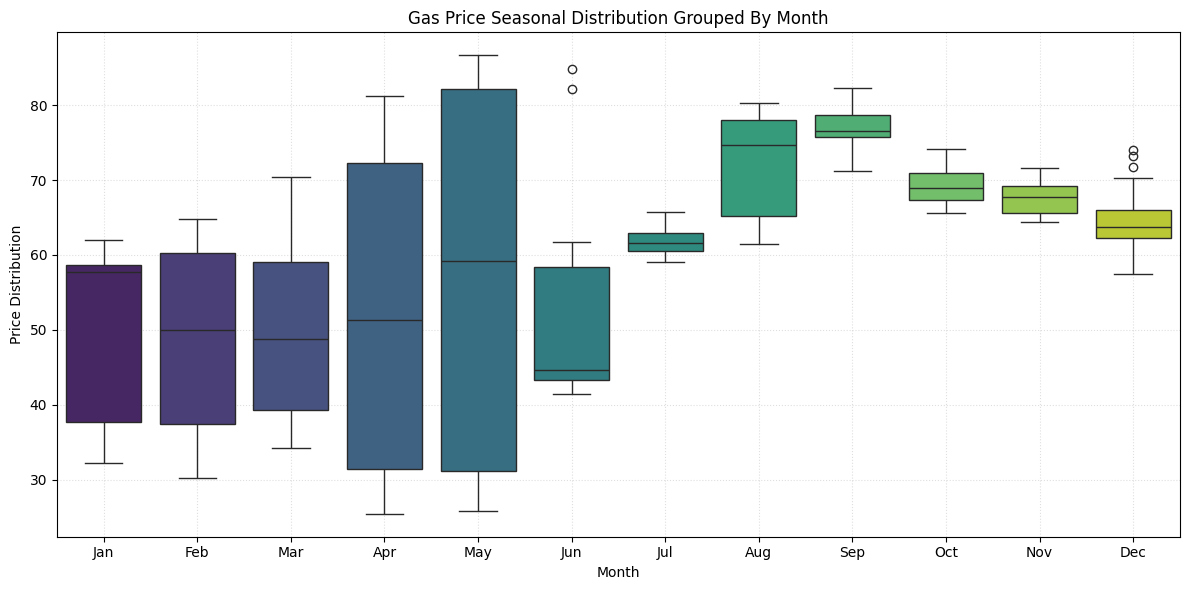

In [14]:
# Categorical distribution tracking seasonal shifts by calendar month
month_order = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

df_seasonal = df.copy()
df_seasonal['Month_Name'] = df_seasonal.index.strftime('%b')
df_seasonal['Month_Name'] = pd.Categorical(df_seasonal['Month_Name'], categories=month_order, ordered=True)

plt.figure(figsize=(12, 6))
sns.boxplot(data=df_seasonal, x='Month_Name', y='daily price', palette='viridis')
plt.title('Gas Price Seasonal Distribution Grouped By Month')
plt.xlabel('Month')
plt.ylabel('Price Distribution')
plt.grid(True, linestyle=':', alpha=0.4)
plt.tight_layout()
plt.show()

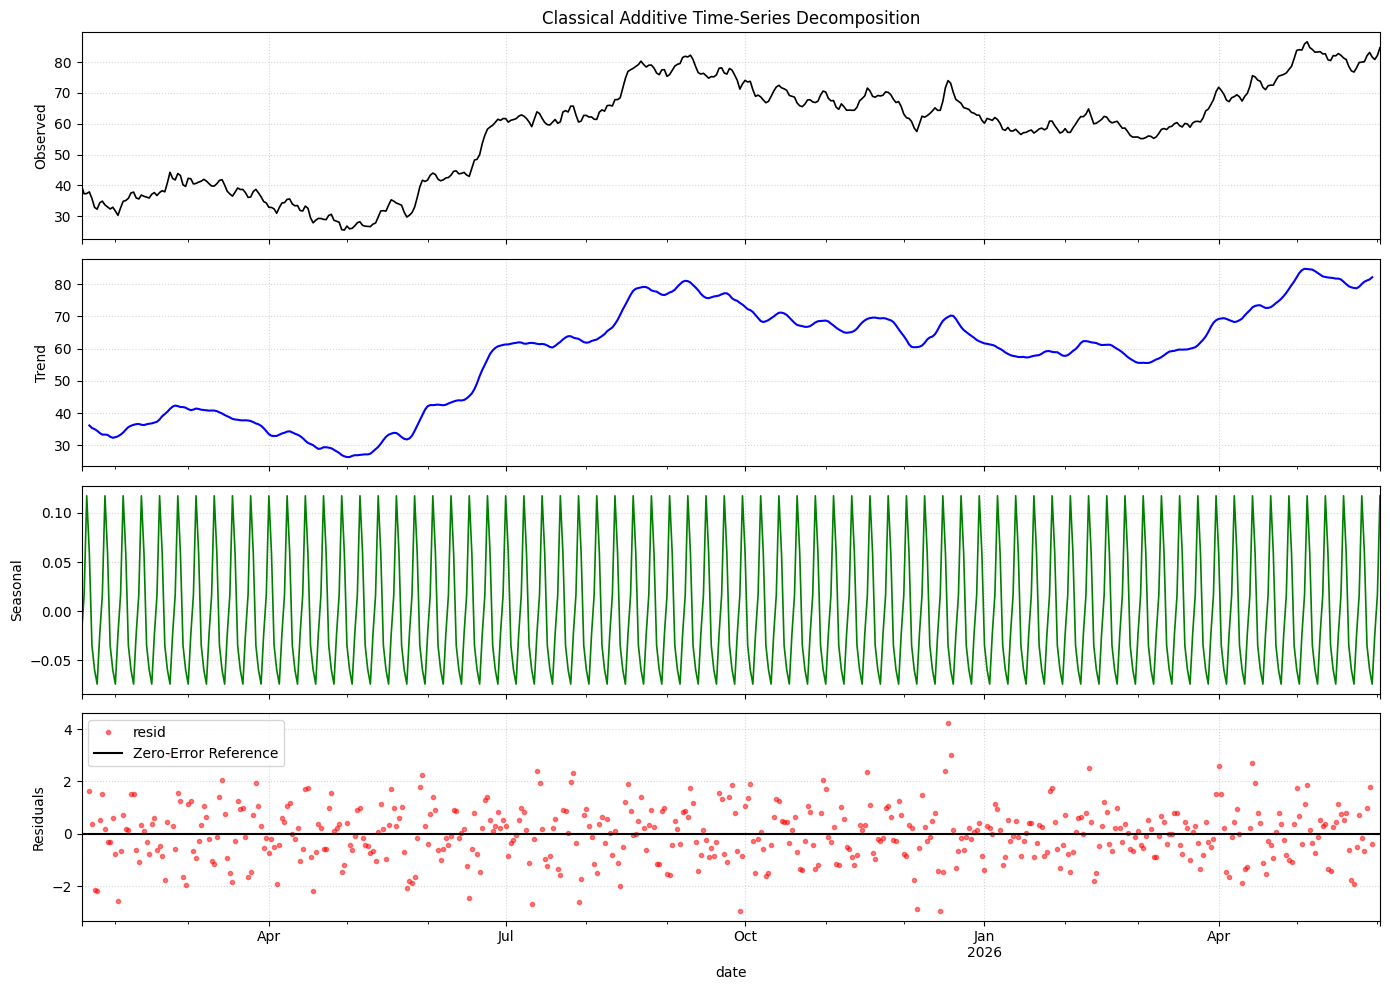

In [15]:
# Extracting underlying time-series components with a weekly period layout
decomposition = seasonal_decompose(df['daily price'], model='additive', period=7)

# Sequentially plotting isolated systematic outputs with explicit controls
fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(14, 10), sharex=True)

decomposition.observed.plot(ax=ax1, color='black', lw=1.2)
ax1.set_ylabel('Observed')
ax1.set_title('Classical Additive Time-Series Decomposition')
ax1.grid(True, linestyle=':', alpha=0.5)

decomposition.trend.plot(ax=ax2, color='blue', lw=1.5)
ax2.set_ylabel('Trend')
ax2.grid(True, linestyle=':', alpha=0.5)

decomposition.seasonal.plot(ax=ax3, color='green', lw=1.2)
ax3.set_ylabel('Seasonal')
ax3.grid(True, linestyle=':', alpha=0.5)

# Plot residuals and draw a solid reference line directly at 0
decomposition.resid.plot(ax=ax4, color='red', style='.', alpha=0.5)
ax4.axhline(y=0, color='black', linestyle='-', lw=1.5, label='Zero-Error Reference')
ax4.set_ylabel('Residuals')
ax4.grid(True, linestyle=':', alpha=0.5)
ax4.legend(loc='upper left')

plt.tight_layout()
plt.show()

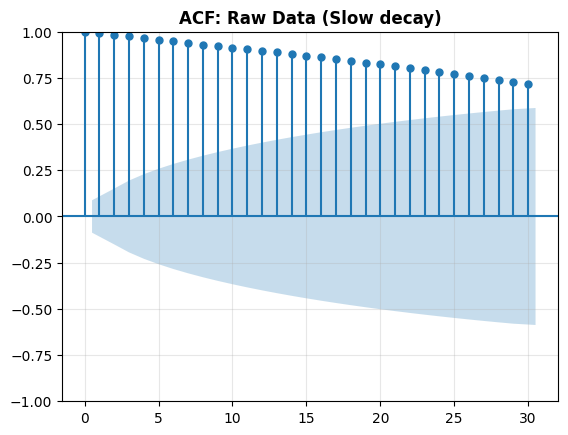

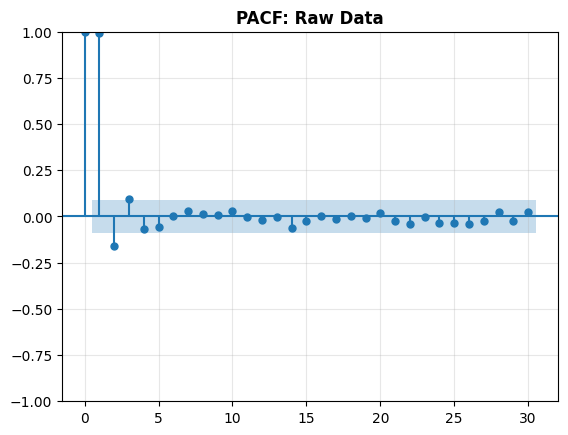

In [16]:
#checking the data for stationary
#from line graph we can see clear trend
#statioanrity checks can be done using the acf and pacf plots

#raw acf
plot_acf(df['daily price'], lags=30)
plt.title('ACF: Raw Data (Slow decay)', fontsize=12, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.show()

#raw pacf
plot_pacf(df['daily price'], lags=30)
plt.title('PACF: Raw Data', fontsize=12, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.show()

clearly the data is unstationary our model arma assumes the data to be stationary, so we have to make the data stationary, we can do that by differencing the price column, we will create new column for our differenced price data

In [17]:
#creating differenced col
df['price_diff'] = df['daily price'].diff()

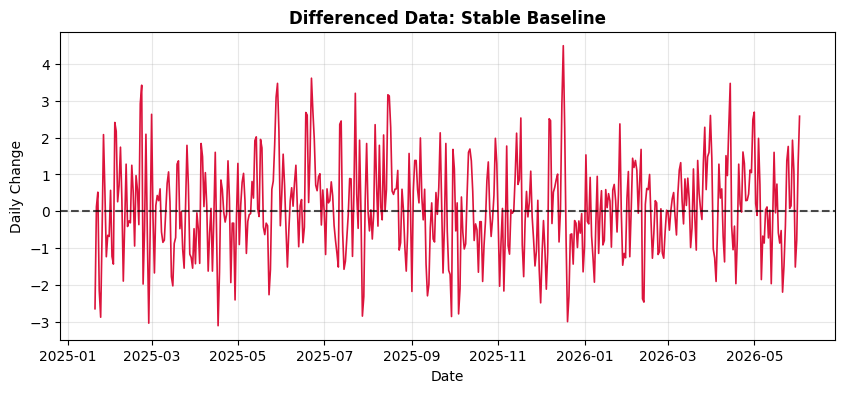

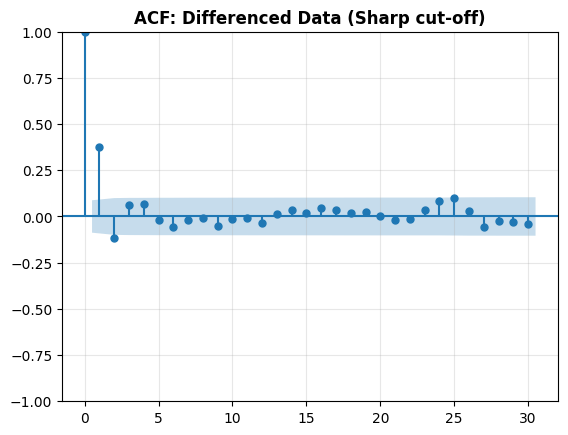

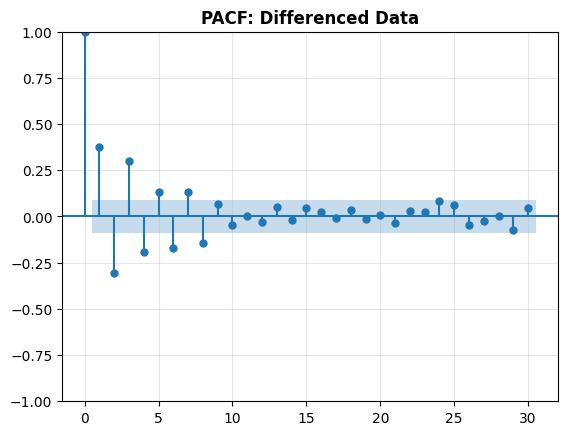

In [18]:
#differenced data lineplot

#remove nan values caused by differencing

diff_clean = df['price_diff'].dropna()

#differenced line

plt.figure(figsize=(10, 4))
plt.plot(diff_clean.index, diff_clean, color='crimson', linewidth=1.2)
plt.axhline(0, color='black', linestyle='--', alpha=0.7)  # Baseline at zero change
plt.title('Differenced Data: Stable Baseline', fontsize=12, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Daily Change')
plt.grid(True, alpha=0.3)
plt.show()

#differenced data acf
plot_acf(diff_clean, lags=30)
plt.title('ACF: Differenced Data (Sharp cut-off)', fontsize=12, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.show()

#differenced data pacf

plot_pacf(diff_clean, lags=30)
plt.title('PACF: Differenced Data', fontsize=12, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.show()

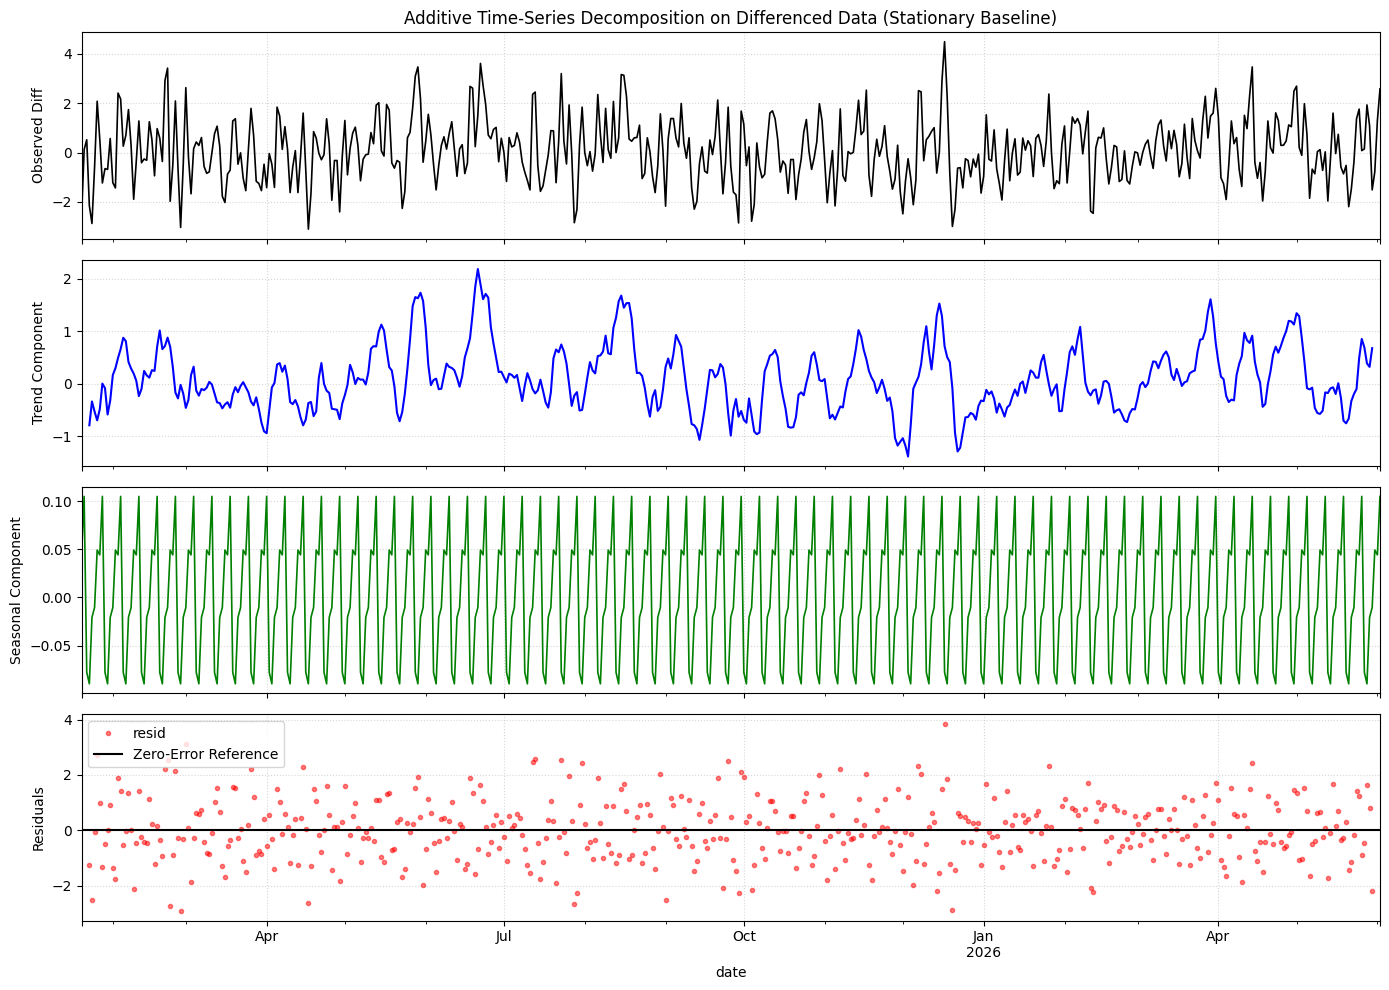

In [ ]:
#first order differencing on the data


df_diff = df[['daily price']].diff().dropna()

#decompose differenced data for weekly cycles
decomposition_diff = seasonal_decompose(df_diff['daily price'], model='additive', period=7)

fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(14, 10), sharex=True)

decomposition_diff.observed.plot(ax=ax1, color='black', lw=1.2)
ax1.set_ylabel('Observed Diff')
ax1.set_title('Additive Time-Series Decomposition on Differenced Data (Stationary Baseline)')
ax1.grid(True, linestyle=':', alpha=0.5)

#Trend component
decomposition_diff.trend.plot(ax=ax2, color='blue', lw=1.5)
ax2.set_ylabel('Trend Component')
ax2.grid(True, linestyle=':', alpha=0.5)

#Seasonal component
decomposition_diff.seasonal.plot(ax=ax3, color='green', lw=1.2)
ax3.set_ylabel('Seasonal Component')
ax3.grid(True, linestyle=':', alpha=0.5)

#Residuals of Differenced Series
decomposition_diff.resid.plot(ax=ax4, color='red', style='.', alpha=0.5)
ax4.axhline(y=0, color='black', linestyle='-', lw=1.5, label='Zero-Error Reference')
ax4.set_ylabel('Residuals')
ax4.grid(True, linestyle=':', alpha=0.5)
ax4.legend(loc='upper left')

plt.tight_layout()
plt.show()

defining models, is the one we are looking at now, arma takes the stationary data, it cant perform on non stationary data, as we will be required to give it the stationary data
the parameter d will be 1 which stands for the data has been differenced once

while arima is a manual model, it can perform on raw data meaning, we can define its parameters (p,d,q) which we are required to do so and as we give the parmeters to loop on the model picks the best differenced data in our case could be 0,1,2 0 stands for raw data, mostly I am assuming model is going to pick d =2 even if we have found the stationarity at d=1(differencing one time)

In [ ]:
#time series train and test split

#80 train 20 test
split_idx = int(len(df) * 0.80)

train_data = df.iloc[:split_idx]
test_data = df.iloc[split_idx:]

print(f"Total Observations: {len(df)} days")
print(f"Training Set Range: {train_data.index.min().strftime('%Y-%m-%d')} to {train_data.index.max().strftime('%Y-%m-%d')} ({len(train_data)} days)")
print(f"Holdout Test Range: {test_data.index.min().strftime('%Y-%m-%d')} to {test_data.index.max().strftime('%Y-%m-%d')} ({len(test_data)} days)")

=== VALIDATION SPLIT DETAILS ===
Total Observations: 500 days
Training Set Range: 2025-01-19 to 2026-02-22 (400 days)
Holdout Test Range: 2026-02-23 to 2026-06-02 (100 days)


so, as we have already split our data, so we have 2 trends in this data which has stochastic and deterministic trend, so whhat happens
is that if have d=1 the model may remove the stochastic trend but may not remove the deterministic trend, so what we can do is cross compare 3 models which are arima(normal where mostly model picks d=1), then we pick the best model where arima(d=2) and also we can introduce the trend component which will be arima+trend and we will compare 3 of them visually on the test set and pick the best model.

In [ ]:
#regular arima
import warnings
warnings.filterwarnings("ignore")

from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error
import numpy as np

y_train = train_data['daily price']      # adjust column name if needed
y_test  = test_data['daily price']

best_aic = float("inf")
best_rmse = float("inf")
best_order = None
best_model = None

print("Running ARIMA grid search...")

for p in range(0, 9):
    for d in range(0, 3):
        for q in range(0, 9):
            try:
                model = ARIMA(y_train, order=(p, d, q)).fit()

                # Forecast the length of the test set
                forecast = model.forecast(steps=len(y_test))

                rmse = np.sqrt(mean_squared_error(y_test, forecast))

                # Select model based on AIC first, RMSE second
                if model.aic < best_aic:
                    best_aic = model.aic
                    best_rmse = rmse
                    best_order = (p, d, q)
                    best_model = model

                print(f"ARIMA{(p,d,q)}  AIC={model.aic:.2f}  RMSE={rmse:.4f}")

            except:
                continue

print("Best Model Found:")
print(f"Order: {best_order}")
print(f"AIC: {best_aic:.2f}")
print(f"RMSE on Test Set: {best_rmse:.4f}")


Running ARIMA grid search...
ARIMA(0, 0, 0)  AIC=3360.72  RMSE=19.0079
ARIMA(0, 0, 1)  AIC=2821.87  RMSE=19.0161
ARIMA(0, 0, 2)  AIC=2325.29  RMSE=19.0083
ARIMA(0, 0, 3)  AIC=2030.96  RMSE=19.0293
ARIMA(0, 0, 4)  AIC=1809.13  RMSE=19.0182
ARIMA(0, 0, 5)  AIC=1692.18  RMSE=19.0390
ARIMA(0, 0, 6)  AIC=1575.40  RMSE=19.0076
ARIMA(0, 0, 7)  AIC=1513.12  RMSE=19.0674
ARIMA(0, 0, 8)  AIC=1461.70  RMSE=19.0404
ARIMA(0, 1, 0)  AIC=1347.56  RMSE=15.0343
ARIMA(0, 1, 1)  AIC=1159.84  RMSE=15.6968
ARIMA(0, 1, 2)  AIC=1158.38  RMSE=15.5245
ARIMA(0, 1, 3)  AIC=1153.82  RMSE=15.4083
ARIMA(0, 1, 4)  AIC=1146.46  RMSE=15.5946
ARIMA(0, 1, 5)  AIC=1148.42  RMSE=15.5777
ARIMA(0, 1, 6)  AIC=1150.38  RMSE=15.6081
ARIMA(0, 1, 7)  AIC=1150.45  RMSE=15.3778
ARIMA(0, 1, 8)  AIC=1152.32  RMSE=15.4034
ARIMA(0, 2, 0)  AIC=1432.40  RMSE=82.5637
ARIMA(0, 2, 1)  AIC=1350.40  RMSE=17.8804
ARIMA(0, 2, 2)  AIC=1164.49  RMSE=13.3128
ARIMA(0, 2, 3)  AIC=1163.19  RMSE=13.0649
ARIMA(0, 2, 4)  AIC=1158.42  RMSE=18.2755
ARIMA

In [ ]:
#arima with d=2
best_aic_d2 = float("inf")
best_rmse_d2 = float("inf")
best_order_d2 = None
best_model_d2 = None

for p in range(0, 9):
    for q in range(0, 9):
        try:
            model = ARIMA(y_train, order=(p, 2, q)).fit()
            forecast = model.forecast(steps=len(y_test))
            rmse = np.sqrt(mean_squared_error(y_test, forecast))

            if model.aic < best_aic_d2:
                best_aic_d2 = model.aic
                best_rmse_d2 = rmse
                best_order_d2 = (p, 2, q)
                best_model_d2 = model

        except:
            continue

print("Best d=2 Model Found:")
print(f"Order: {best_order_d2}")
print(f"AIC: {best_aic_d2:.2f}")
print(f"RMSE on Test Set: {best_rmse_d2:.4f}")



Best d=2 Model Found:
Order: (7, 2, 7)
AIC: 1146.38
RMSE on Test Set: 12.6210


In [ ]:
#arima+trend
best_aic_trend = float("inf")
best_rmse_trend = float("inf")
best_order_trend = None
best_model_trend = None

print("Running ARIMA grid search WITH trend='t' ...")

for p in range(0, 9):
    for d in range(0, 3):
        for q in range(0, 9):
            try:
                model = ARIMA(y_train, order=(p, d, q), trend='t').fit()

                # Forecast the test horizon
                forecast = model.forecast(steps=len(y_test))
                rmse = np.sqrt(mean_squared_error(y_test, forecast))

                if model.aic < best_aic_trend:
                    best_aic_trend = model.aic
                    best_rmse_trend = rmse
                    best_order_trend = (p, d, q)
                    best_model_trend = model

                print(f"ARIMA{(p,d,q)} + trend  AIC={model.aic:.2f}  RMSE={rmse:.4f}")

            except:
                continue

print("Best Trend Model Found:")
print(f"Order: {best_order_trend}")
print(f"AIC: {best_aic_trend:.2f}")
print(f"RMSE on Test Set: {best_rmse_trend:.4f}")


Running ARIMA grid search WITH trend='t' ...
ARIMA(0, 0, 0) + trend  AIC=3551.09  RMSE=33.1300
ARIMA(0, 0, 1) + trend  AIC=3013.46  RMSE=32.8557
ARIMA(0, 0, 2) + trend  AIC=2507.66  RMSE=32.6253
ARIMA(0, 0, 3) + trend  AIC=2183.16  RMSE=32.4066
ARIMA(0, 0, 4) + trend  AIC=1935.24  RMSE=32.7126
ARIMA(0, 0, 5) + trend  AIC=1807.17  RMSE=31.8270
ARIMA(0, 0, 6) + trend  AIC=1676.75  RMSE=31.6177
ARIMA(0, 0, 7) + trend  AIC=1602.78  RMSE=31.2995
ARIMA(0, 0, 8) + trend  AIC=1541.35  RMSE=31.0510
ARIMA(0, 1, 0) + trend  AIC=1348.99  RMSE=12.3022
ARIMA(0, 1, 1) + trend  AIC=1161.64  RMSE=13.3115
ARIMA(0, 1, 2) + trend  AIC=1160.10  RMSE=13.0460
ARIMA(0, 1, 3) + trend  AIC=1155.46  RMSE=12.8329
ARIMA(0, 1, 4) + trend  AIC=1148.21  RMSE=13.1409
ARIMA(0, 1, 5) + trend  AIC=1150.15  RMSE=13.1066
ARIMA(0, 1, 6) + trend  AIC=1152.13  RMSE=13.1508
ARIMA(0, 1, 7) + trend  AIC=1152.11  RMSE=12.7737
ARIMA(0, 1, 8) + trend  AIC=1154.00  RMSE=12.8236
ARIMA(1, 0, 0) + trend  AIC=1361.00  RMSE=12.0911
ARIMA

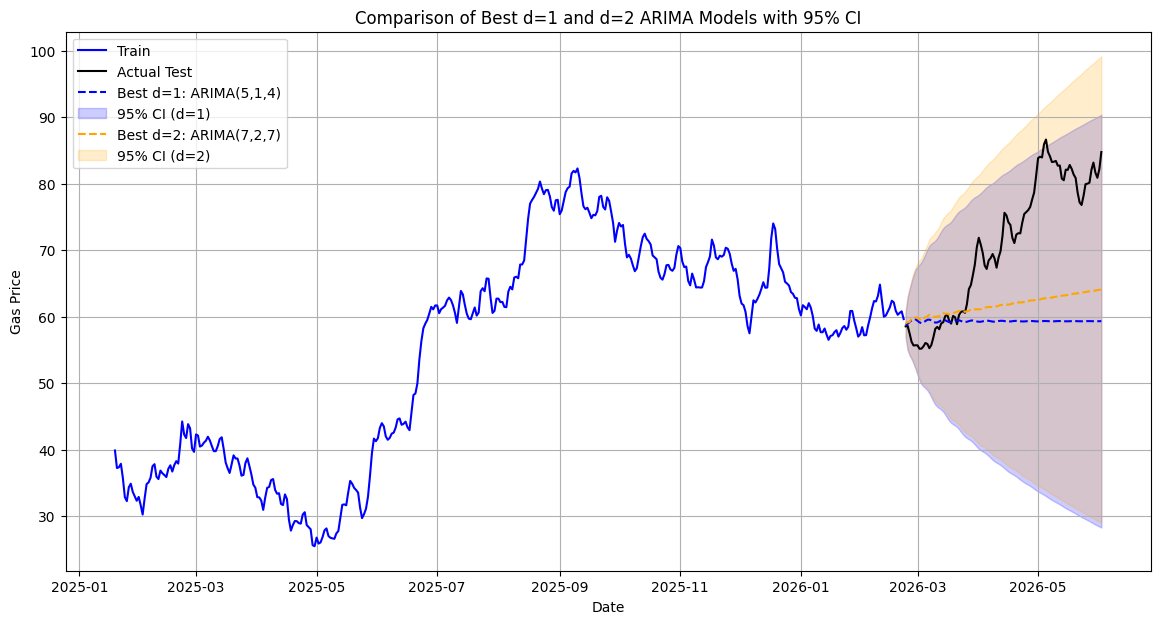

In [ ]:
import matplotlib.pyplot as plt

#fit two models
model_d1 = ARIMA(y_train, order=(5,1,4)).fit()
model_d2 = ARIMA(y_train, order=(7,2,7)).fit()

#forecast test horizon
fc_d1 = model_d1.get_forecast(steps=len(y_test))
fc_d2 = model_d2.get_forecast(steps=len(y_test))

d1_mean = fc_d1.predicted_mean
d1_ci = fc_d1.conf_int()

d2_mean = fc_d2.predicted_mean
d2_ci = fc_d2.conf_int()

plt.figure(figsize=(14,7))

#train
plt.plot(y_train.index, y_train, label="Train", color="blue")

#test
plt.plot(y_test.index, y_test, label="Actual Test", color="black")

#d=1 forecast
plt.plot(y_test.index, d1_mean, label="Best d=1: ARIMA(5,1,4)", linestyle="--", color="blue")
plt.fill_between(
    y_test.index,
    d1_ci.iloc[:,0],
    d1_ci.iloc[:,1],
    color="blue",
    alpha=0.2,
    label="95% CI (d=1)"
)

#d=2 forecast
plt.plot(y_test.index, d2_mean, label="Best d=2: ARIMA(7,2,7)", linestyle="--", color="orange")
plt.fill_between(
    y_test.index,
    d2_ci.iloc[:,0],
    d2_ci.iloc[:,1],
    color="orange",
    alpha=0.2,
    label="95% CI (d=2)"
)

plt.title("Comparison of Best d=1 and d=2 ARIMA Models with 95% CI")
plt.xlabel("Date")
plt.ylabel("Gas Price")
plt.legend()
plt.grid(True)
plt.show()


as our model d=2 (7,2,7) is the winner now we will compare that with our trend plot to confirm which is our best model

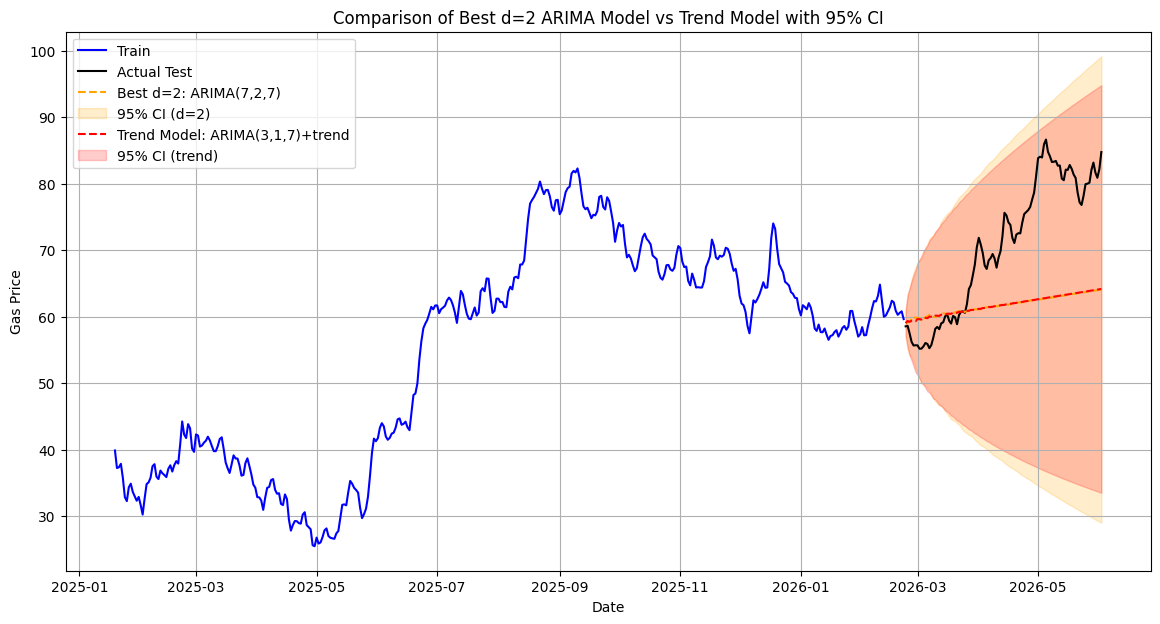

In [ ]:
import matplotlib.pyplot as plt

#fir d=2 model and trend model
model_d2 = ARIMA(y_train, order=(7,2,7)).fit()
model_trend = ARIMA(y_train, order=(3,1,7), trend='t').fit()

fc_d2 = model_d2.get_forecast(steps=len(y_test))
fc_trend = model_trend.get_forecast(steps=len(y_test))

d2_mean = fc_d2.predicted_mean
d2_ci = fc_d2.conf_int()

trend_mean = fc_trend.predicted_mean
trend_ci = fc_trend.conf_int()

plt.figure(figsize=(14,7))


plt.plot(y_train.index, y_train, label="Train", color="blue")


plt.plot(y_test.index, y_test, label="Actual Test", color="black")

#d=2 forecast
plt.plot(y_test.index, d2_mean, label="Best d=2: ARIMA(7,2,7)", linestyle="--", color="orange")
plt.fill_between(
    y_test.index,
    d2_ci.iloc[:,0],
    d2_ci.iloc[:,1],
    color="orange",
    alpha=0.2,
    label="95% CI (d=2)"
)

#trend model forecast
plt.plot(y_test.index, trend_mean, label="Trend Model: ARIMA(3,1,7)+trend", linestyle="--", color="red")
plt.fill_between(
    y_test.index,
    trend_ci.iloc[:,0],
    trend_ci.iloc[:,1],
    color="red",
    alpha=0.2,
    label="95% CI (trend)"
)

plt.title("Comparison of Best d=2 ARIMA Model vs Trend Model with 95% CI")
plt.xlabel("Date")
plt.ylabel("Gas Price")
plt.legend()
plt.grid(True)
plt.show()


We compared the best d=2 ARIMA model with the best trend-augmented ARIMA model using both AIC and RMSE:

ARIMA(7,2,7)
AIC = 1146.38
RMSE = 12.6210

ARIMA(3,1,7) + trend='t'  
AIC = 1147.18
RMSE = 12.5764


trend model achieves a lower RMSE, meaning it predicts the test data more accurately.  
AIC difference is only 0.80**, which is less than the threshold of 2 
therefore, AIC does not provide a statistically significant advantage to the d=2 model.  
The trend model is also more stable and interpretable, as it explicitly captures the deterministic trend rather than relying on second differencing.

Although ARIMA(7,2,7) has a slightly lower AIC, the difference is negligible.  
Given its better RMSE, greater stability, and theoretical justification, the  
ARIMA(3,1,7) + trend='t' model is selected as the final model for forecasting.


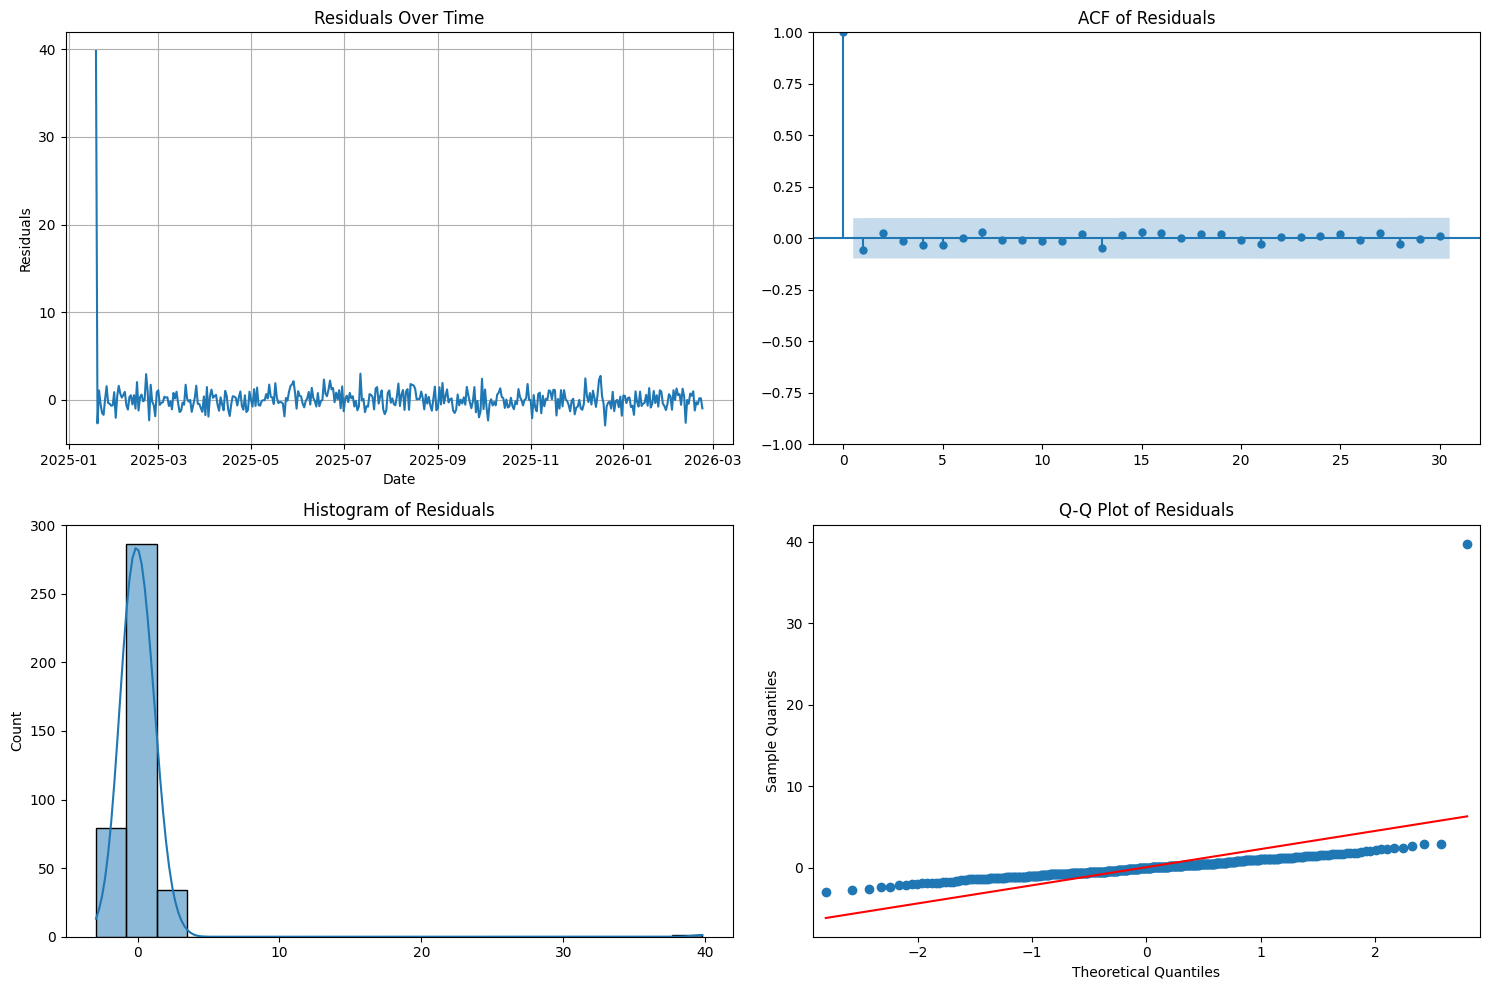

Ljung-Box Test Results:
     lb_stat  lb_pvalue
10  2.940000   0.982801
20  5.107225   0.999673
30  6.432568   0.999998


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.gofplots import qqplot
from statsmodels.stats.diagnostic import acorr_ljungbox

#fit final model on full data
final_model = ARIMA(y_train, order=(3,1,7), trend='t').fit()

#residuals
residuals = final_model.resid

plt.figure(figsize=(15,10))

#residual time series
plt.subplot(2,2,1)
plt.plot(residuals)
plt.title("Residuals Over Time")
plt.xlabel("Date")
plt.ylabel("Residuals")
plt.grid(True)

#acf
plt.subplot(2,2,2)
plot_acf(residuals, ax=plt.gca(), lags=30)
plt.title("ACF of Residuals")

#histogram of residuals
plt.subplot(2,2,3)
sns.histplot(residuals, kde=True, bins=20)
plt.title("Histogram of Residuals")

#QQ plots
plt.subplot(2,2,4)
qqplot(residuals, line='s', ax=plt.gca())
plt.title("Q-Q Plot of Residuals")

plt.tight_layout()
plt.show()

#Ljung box
lb_test = acorr_ljungbox(residuals, lags=[10, 20, 30], return_df=True)
print("Ljung-Box Test Results:")
print(lb_test)


In [40]:
print(y.index)


DatetimeIndex(['2025-01-19', '2025-01-20', '2025-01-21', '2025-01-22',
               '2025-01-23', '2025-01-24', '2025-01-25', '2025-01-26',
               '2025-01-27', '2025-01-28',
               ...
               '2026-05-24', '2026-05-25', '2026-05-26', '2026-05-27',
               '2026-05-28', '2026-05-29', '2026-05-30', '2026-05-31',
               '2026-06-01', '2026-06-02'],
              dtype='datetime64[ns]', name='date', length=500, freq=None)


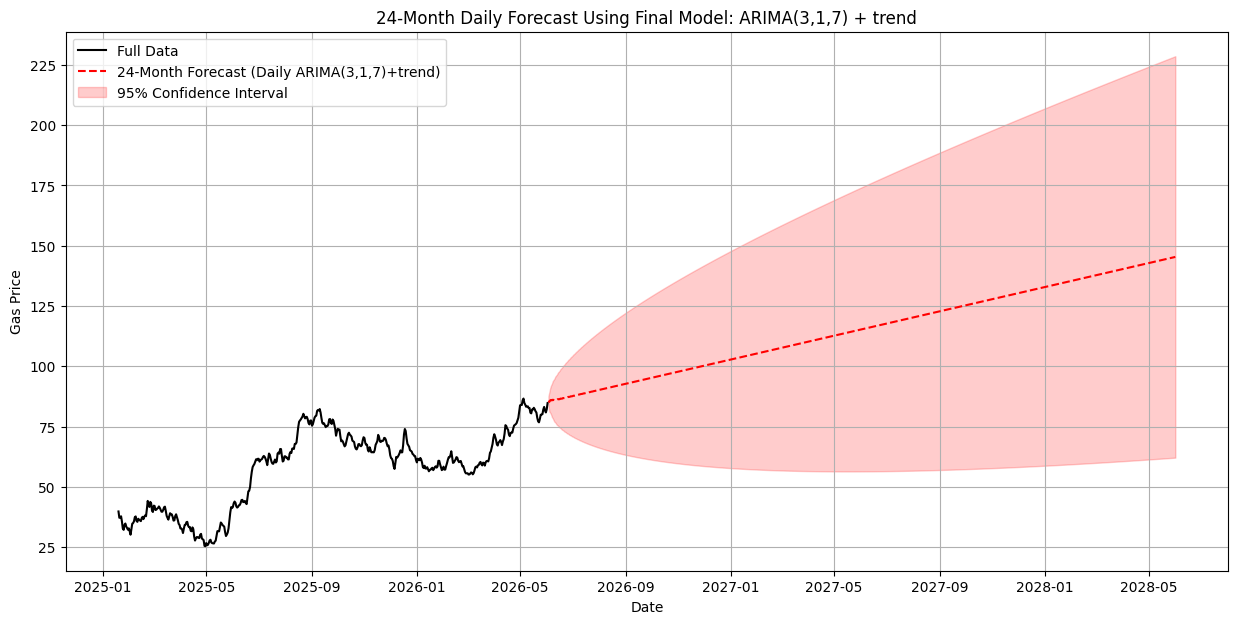

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
from statsmodels.tsa.arima.model import ARIMA

#full dataset
y = df['daily price']   

#fit final model
final_model_full = ARIMA(y, order=(3,1,7), trend='t').fit()

#forecast 24 months 2x365=730 days
forecast_steps = 730
fc = final_model_full.get_forecast(steps=forecast_steps)

fc_mean = fc.predicted_mean
fc_ci = fc.conf_int()

#daily future index
future_index = pd.date_range(
    start=y.index[-1] + pd.Timedelta(days=1),
    periods=forecast_steps,
    freq='D'
)

#plot
plt.figure(figsize=(15,7))

plt.plot(y.index, y, label="Full Data", color="black")

plt.plot(future_index, fc_mean,
         label="24-Month Forecast (Daily ARIMA(3,1,7)+trend)",
         linestyle="--", color="red")

plt.fill_between(
    future_index,
    fc_ci.iloc[:,0],
    fc_ci.iloc[:,1],
    color="red",
    alpha=0.2,
    label="95% Confidence Interval"
)

plt.title("24-Month Daily Forecast Using Final Model: ARIMA(3,1,7) + trend")
plt.xlabel("Date")
plt.ylabel("Gas Price")
plt.legend()
plt.grid(True)
plt.show()
